# Winnipeg Naloxone Administrations (2007 to 2026)
**Prepared by:** Renato Landi  
**Source:** Winnipeg Open Data Portal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import helper module
import sys
sys.path.insert(0, '..')
from src.helpers import (plot_incidents_by_year, plot_temporal_patterns,
                         plot_ward_incidents, plot_income_scatter,
                         plot_multiple_dose_heatmap, clean_dataset,
                         prepare_data_for_train ,train_evaluate_dt) 

df = pd.read_csv("../data/naloxone.csv") # main dataset

wards = pd.read_csv("../data/ward_demographics.csv") # supplementary dataset

## 1. Initial Exploration Summary

The dataset contains **26,322 rows and 10 columns**, covering naloxone incidents attended by Winnipeg EMS from **2007 to 2026**.

**Key findings:**

- `Dispatch Date` was stored as plain text and needed to be parsed into separate columns (year, month, hour, etc.)
- `Age` uses string ranges like "30 to 34" and was converted to a numeric midpoint
- Both `Age` and `Gender` mix real `NaN` with the string `"Unknown"`, standardized during cleaning
- Incidents are heavily concentrated in 3 wards: **Point Douglas**, **Daniel McIntyre**, and **Mynarski**

**Analytical questions:**

**1. How have naloxone incidents evolved over the years?**

**2. Are there temporal patterns in when incidents occur (hour, day of week)?**

**3. Which wards are most affected and why?**

**4. Is age or gender related to needing multiple doses?**


## 2. Data Cleaning and Transformations
**Transformations Summary:**
- Rename columns: converted all column names to snake_case; fixed typo `"naxolone"` -> `"naloxone"`.

- Drop columns: removed `id`, `neighbourhood`, and `neighobourhood_id`.

- Expand `dispatch_date`: parsed `dispatch_date` to datetime; extracted `year`, `month`, `day_of_week`, `hour`, and `date` as separate columns; dropped original column `dispatch_date`.

- Standardize missing values: replaced `"Unknown"` strings in `age` and `gender` columns with real `NaN`.

- Create `age_midpoint` column: calculated numeric midpoint from age range strings to float (ex: `"25 to 29"` -> `27.0`); kept original column `age` with the strings age ranges.

- Create `is_multiple_dose` boolean column: useful for severity analysis.

- Reorder columns: reordered dataset columns to show in a more readable way.

In [2]:
df = clean_dataset(df)
df.head(3)

,incident_number,patient_number,date,year,month,day_of_week,hour,age,age_midpoint,gender,ward,naloxone_administrations,is_multiple_dose
0,2021095567,1,2021-08-08,2021,8,6,4,30 to 34,32.0,Male,NaN,1,False
1,2021095606,1,2021-08-08,2021,8,6,7,55 to 59,57.0,Female,Fort Rouge - East Fort Garry,1,False
2,2021095828,1,2021-08-08,2021,8,6,16,50 to 54,52.0,Female,Fort Rouge - East Fort Garry,1,False


## 3. Analysis

### 3.1 Q1. How have naloxone incidents evolved over the years?
This chart shows the total number of incidents registered and the total number of naloxone doses administered for each year from 2008-2025 (2007 and 2026 excluded because of partial data, making the chart misleading).

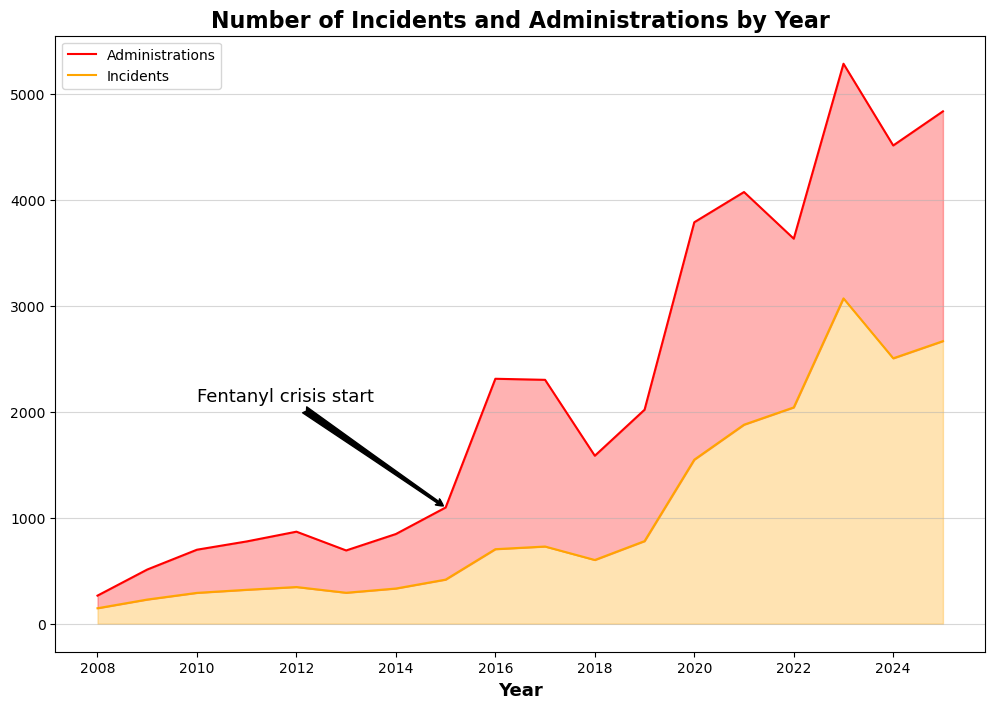

In [3]:
plot_incidents_by_year(df)

Incidents have grown steadily since 2008, with a sharp spike between 2016 and 2018. The year of 2016 marked a dramatic escalation of fentanyl in Winnipeg's drug supply ([CBC News, 2016](https://www.cbc.ca/news/canada/manitoba/winnipeg-fentanyl-user-1.3527976)), which explains why administrations spiked much faster than incidents during that time... The gap between the two lines is a measure of how much more dangerous drugs became over time.

### 3.2 Q2. Are there temporal patterns in when incidents occur?
This chart breaks down incidents by day of the week and by hour of the day, to see if overdoses cluster at specific times.

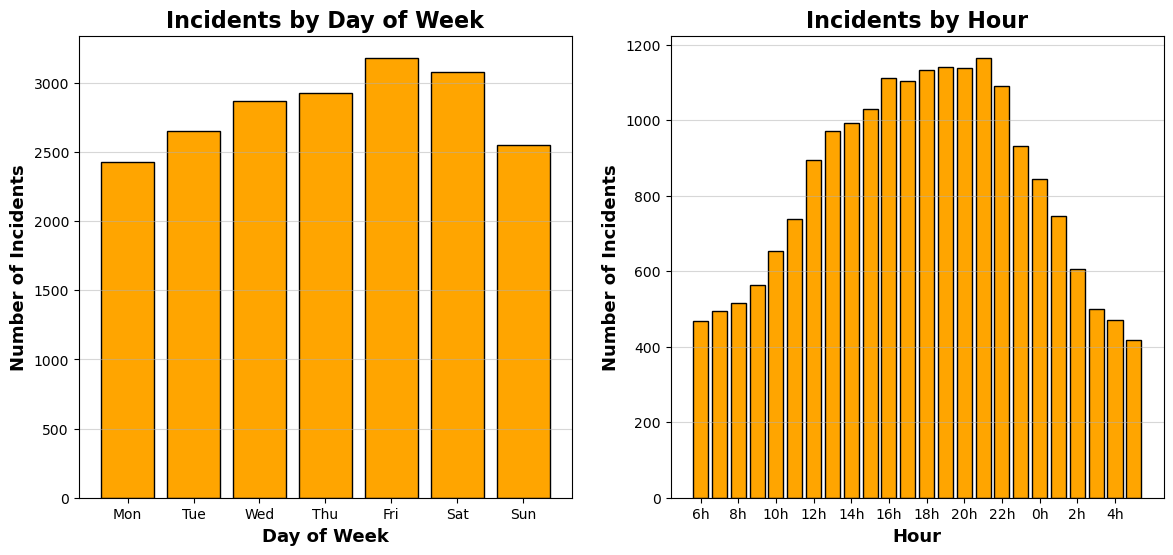

In [4]:
plot_temporal_patterns(df)

Incidents are relatively consistent across all days of the week, with a slight peak on Fridays and Saturdays. The hour chart tells a clearer story: incident volume appears to follow daily activity cycles, with a low point at 5am and a gradual buildup throughout the day, peaking at 8pm before declining through the night.

### 3.3 Q3. Which wards are most affected and why??
The visualizations below explore the geographic distribution of incidents across Winnipeg's 15 wards and whether socioeconomic factors might help explain the differences between them.

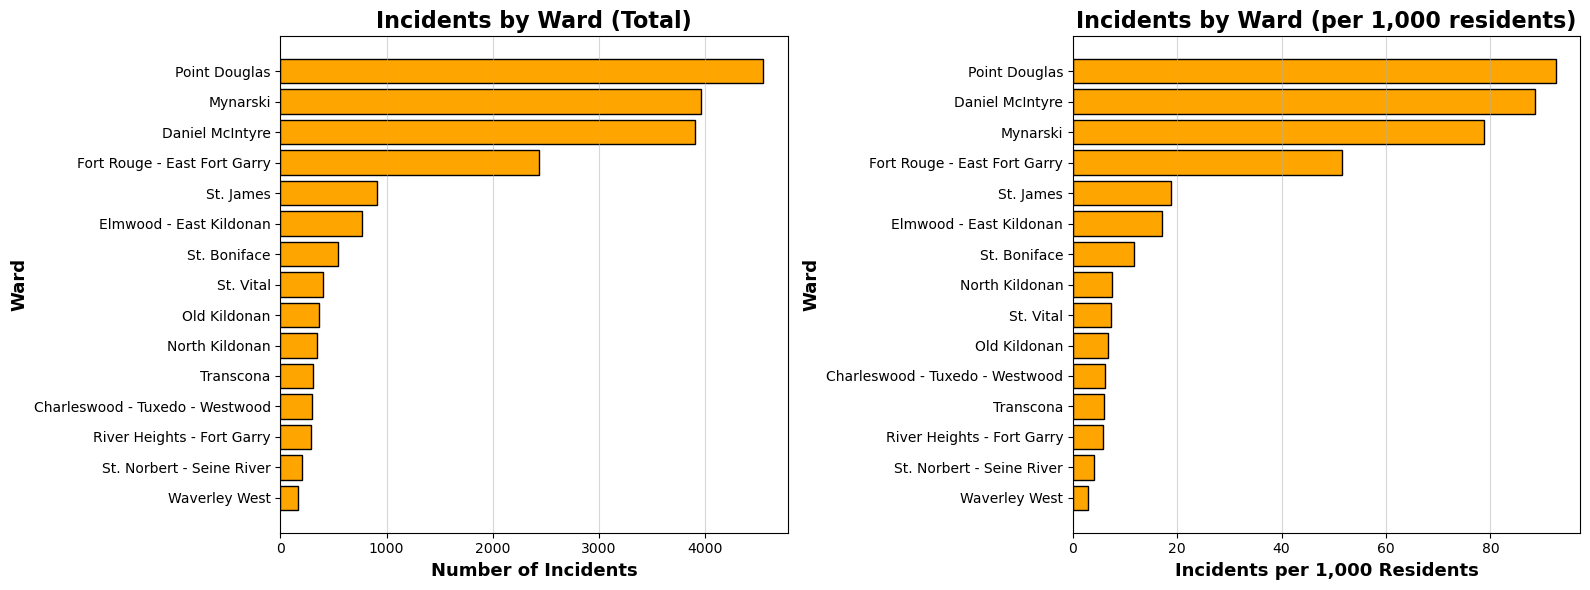

In [5]:
plot_ward_incidents(df, wards)

Point Douglas, Mynarski, and Daniel McIntyre lead in both total incidents and incidents per 1,000 residents, which rules out population size as an explanation. This raises the question: what makes these wards different? The chart below looks at whether median household income might help explain the pattern.

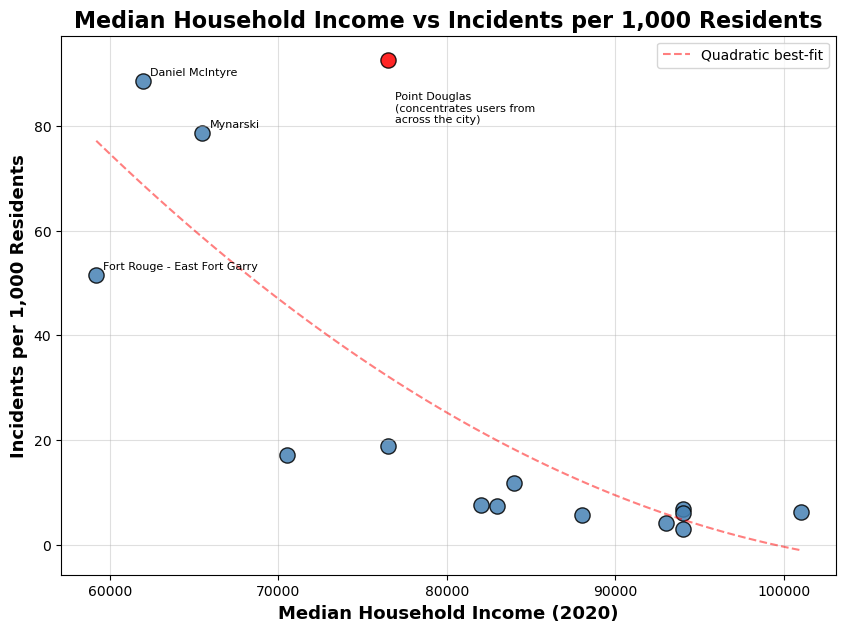

In [6]:
plot_income_scatter(df, wards)

The relationship between income and overdose rate is clearly negative. The four labeled wards, Point Douglas, Mynarski, Daniel McIntyre, and Fort Rouge, are the ones with the lowest median household incomes and the highest incidents per 1,000 residents. The pattern is not linear: below roughly $80,000 in median income, overdose rates are really higher, while above that level the numbers stay consistently low. This suggests that income plays a much bigger role in overdose risk than population size, and that where someone lives in Winnipeg is closely related to how wealthy their ward is.

Point Douglas (highlighted in red) is an exception worth noting. Its median income is not the lowest among the wards, yet it has the highest overdose rate by far. This is likely because Point Douglas sits next to downtown Winnipeg, an area that concentrates people who use drugs from across the city, not just local residents. Manitoba health surveillance data indicates that over half of all naloxone calls attended by Winnipeg paramedics between January and June 2017 occurred in the Downtown / Point Douglas areas. ([Government of Manitoba, 2017](https://www.gov.mb.ca/health/publichealth/surveillance/docs/opioid/2017/q2_opioid.pdf))

### 3.4 Q4. Is age or gender related to needing multiple doses?
This visualization will look for patterns in demographics charachteristics like age and gender to see if they relate to the necessity of multiple doses.

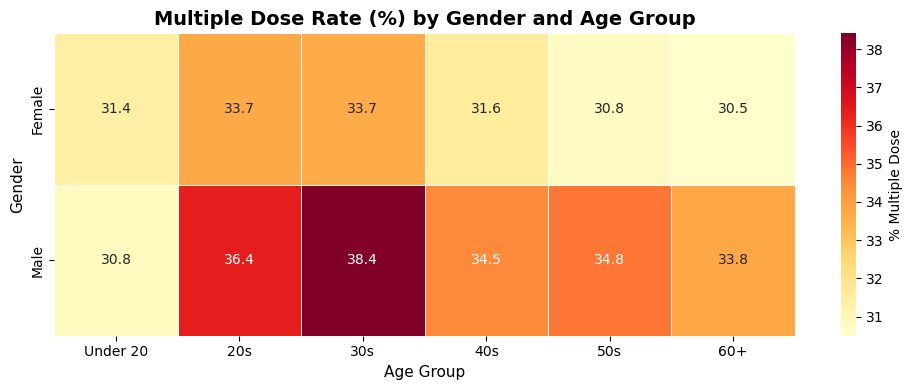

In [7]:
plot_multiple_dose_heatmap(df)

The visual clearly shows a darker Male section, meaning that males have more severe incidents. Males in their 20s and 30s are the most likely to need multiple doses, with 36.4% and 38.4% respectively. Females show a much more stable pattern across all age groups, but still peaking at the 20s and 30s. For paramedics teams, this means that calls involving young/adult male patients may be more likely to require extra doses on hand.

## 4. Prediction
The analysis showed that demographic and temporal features have a measurable but weak relationship with incident severity. This section takes that a step further by training a Decision Tree classifier to predict whether a patient will need multiple doses of naloxone (`is_multiple_dose`), using age, gender, ward, hour, day of week, month, and year as features.

Given what the analysis already revealed, a perfect model is not the expectation here. The pattern exists but it is subtle, so a model that performs clearly above chance but well below a strong classifier is exactly the expected outcome.

### 4.1 Training and Evaluating the Model (Decision Tree)

In [8]:
X_train, X_test, y_train, y_test = prepare_data_for_train(df)
train_evaluate_dt(X_train, X_test, y_train, y_test)

Accuracy: 0.6009
F1: 0.4798
Recall: 0.5327
Precision: 0.4365


DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)

### 4.2 Results Evaluation

Accuracy of 0.60, F1 of 0.48, recall of 0.53, and precision of 0.44. Exactly what was expected: the model is learning something real, but the signal is weak. A random guess would sit at 50% accuracy, so the model found a real pattern that someway separates the data, just not by a lot.

This lines up with the analysis findings. The patterns in more severy incidents exist (younger adult males tend to need more doses), but they are not strong enough to predict individual incidents reliably. Demographics and time alone do not tell the full story.
